# Exploratory Data Analysis (EDA)

# Demographics

In [22]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [23]:
from pathlib import Path
# load data to df
root = Path().resolve().parent
#print(root)
cleaned_data_path = root / "data"/"processed"/"bank-full-clean.csv"
#print(cleaned_data_path)
df = pd.read_csv(cleaned_data_path, sep = ",")  # specify comma as separater

# display first 10 rows of df
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


### Question 1: Which age groups are most likely to subscribe to a term deposit?

/var/folders/m9/3qw5qv8x7bdb20d_n3wnbqpm0000gn/T/ipykernel_50676/3693501520.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


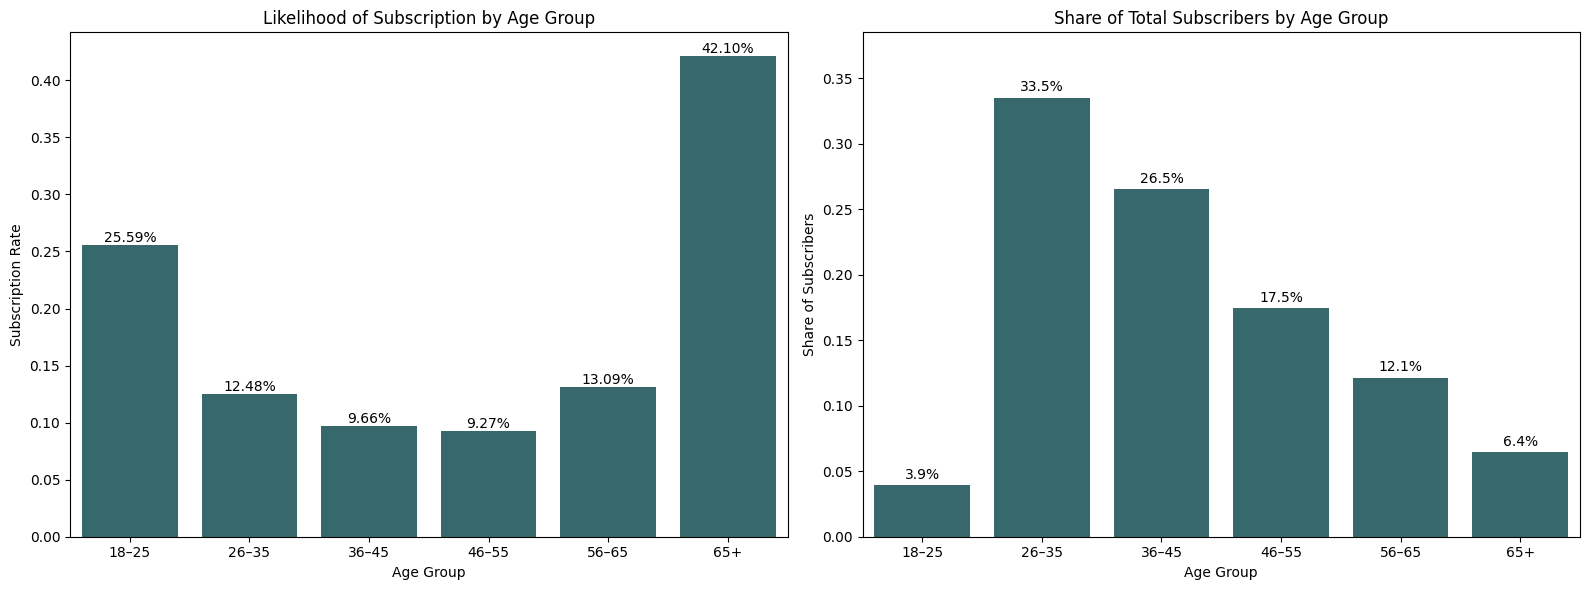

In [24]:
#----------------------------------------
# Create age bins
#----------------------------------------
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18–25', '26–35', '36–45', '46–55', '56–65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

#----------------------------------------
# Prepare data
#----------------------------------------
df['subscribed'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

subscriber_volume = (
    df[df['y'] == 'yes']['age_group']
    .value_counts(normalize=True)
    .sort_index()
)

#----------------------------------------
# Side-by-side plots
#----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Subscription Rate by Age Group ---
ax1 = axes[0]
sns.barplot(
    data=df,
    x='age_group',
    y='subscribed',
    ci=None,
    ax=ax1,
    color = '#2F6F73'
)

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.2%}",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom')

ax1.set_title("Likelihood of Subscription by Age Group")
ax1.set_xlabel("Age Group")
ax1.set_ylabel("Subscription Rate")

# --- Plot 2: Share of All Subscribers by Age Group ---
ax2 = axes[1]
sns.barplot(
    x=subscriber_volume.index,
    y=subscriber_volume.values,
    color='#2F6F73',
    ax=ax2
)

ax2.set_title("Share of Total Subscribers by Age Group")
ax2.set_xlabel("Age Group")
ax2.set_ylabel("Share of Subscribers")
ax2.set_ylim(0, subscriber_volume.max() + 0.05)

for i, v in enumerate(subscriber_volume.values):
    ax2.text(i, v + 0.005, f"{v:.1%}", ha='center')

plt.tight_layout()
plt.show()



### #Insights
> * Age 65+ customers has highest conversion 
> * Age 26-45 is a larger group of subscribers but have low responsiveness

In [28]:
# Target Matrix with plotly to show the target segments based on subscription likelihood and subscriber volume by age group

import pandas as pd
import plotly.express as px

# --- Prepare data ---
df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)

# Likelihood table
likelihood = df.groupby('age_group')['y_binary'].mean().reset_index()
likelihood.rename(columns={'y_binary': 'likelihood'}, inplace=True)

# Volume table (share of all subscribers)
subscriber_counts = df[df['y'] == 'yes'].groupby('age_group').size().reset_index(name='subscriber_count')
total_subscribers = subscriber_counts['subscriber_count'].sum()
subscriber_counts['volume_share'] = subscriber_counts['subscriber_count'] / total_subscribers

# Sample size table
sample_size = df.groupby('age_group').size().reset_index(name='sample_size')

# Merge all metrics
merged = likelihood.merge(subscriber_counts, on='age_group', how='left')
merged = merged.merge(sample_size, on='age_group', how='left')
merged['volume_share'] = merged['volume_share'].fillna(0)

# --- Compute thresholds ---
likelihood_threshold = merged['likelihood'].median()
volume_threshold = merged['volume_share'].median()

# --- Assign quadrant labels ---
def classify_quadrant(row):
    if row['volume_share'] >= volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Prime Target"
    elif row['volume_share'] >= volume_threshold and row['likelihood'] < likelihood_threshold:
        return "Improvement Opportunity"
    elif row['volume_share'] < volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Niche / Unstable"
    else:
        return "Low Priority"

merged['quadrant'] = merged.apply(classify_quadrant, axis=1)

# --- Quadrant color map ---
quadrant_colors = {
    "Prime Target":  "#1f77b4",              # blue
    "Improvement Opportunity": "#ff7f0e",  # orange
    "Niche / Unstable": "#2ca02c",          # green
    "Low Priority": "#d62728"         # red 
}

# --- Base scatter ---
fig = px.scatter(
    merged,
    x='volume_share',
    y='likelihood',
    color='quadrant',
    size='sample_size',
    hover_data={
        "age_group": True,
        "likelihood": ":.2%",
        "volume_share": ":.2%",
        "sample_size": True,
        "subscriber_count": True,
        "quadrant": True
    },
    title="Age Target Matrix: Subscription Likelihood vs Subscriber Volume",
    labels={'volume_share': 'Share of All Subscribers', 'likelihood': 'Subscription Likelihood'},
    size_max=55,
    color_discrete_map=quadrant_colors
)

# Add quadrant reference lines
fig.add_hline(y=likelihood_threshold, line_dash="dash", line_color="gray")
fig.add_vline(x=volume_threshold, line_dash="dash", line_color="gray")

fig.update_layout(width=900, height=650, legend_title_text="Segment Type")

# --- Quadrant labels ---
x_min, x_max = merged['volume_share'].min(), merged['volume_share'].max()
y_min, y_max = merged['likelihood'].min(), merged['likelihood'].max()

x_left  = (x_min + volume_threshold) / 2
x_right = (volume_threshold + x_max) / 2 
y_bottom = (y_min + likelihood_threshold) / 2 # not used but calculated for consistency
y_top    = (likelihood_threshold + y_max) / 2

# for improving the readability of "Improvement Opportunity" and "Low Priority" labels in the graph, we set a specific location for it
x_improve = volume_threshold + (x_max - volume_threshold) * 0.95
y_improve = y_min + (likelihood_threshold - y_min) * -1.05

fig.add_annotation(x=x_right, y=y_top, text="Prime Target", showarrow=False, font=dict(size=14, color= "#1f77b4"))
fig.add_annotation(x=x_improve, y=y_improve, text="Improvement Opportunity", showarrow=False, font=dict(size=14, color="#ff7f0e"))
fig.add_annotation(x=x_left, y=y_top, text="Niche / Unstable", showarrow=False, font=dict(size=14, color= "#2ca02c"))
fig.add_annotation(x=x_left, y=y_improve, text="Low Priority", showarrow=False, font=dict(size=14, color="#d62728"))

# --- Bubble labels ---
for _, row in merged.iterrows():

    label_text = (
        f"<b>{row['age_group']}</b><br>"
        f"Lik: {row['likelihood']:.1%}<br>"
        f"Vol: {row['volume_share']:.1%}"
    )

    if row['volume_share'] < volume_threshold:
        xanchor = "right"
        xshift = -10
    else:
        xanchor = "left"
        xshift = 10

    fig.add_annotation(
        x=row['volume_share'],
        y=row['likelihood'],
        text=label_text,
        showarrow=False,
        font=dict(size=11, color="black"),
        align="left",
        xanchor=xanchor,
        yanchor="middle",
        xshift=xshift,
        bgcolor="rgba(255,255,255,0.75)",
        bordercolor="rgba(0,0,0,0.25)",
        borderwidth=1,
        borderpad=3
    )
    # Add information box explaining quadrants
    fig.add_annotation(
        x=1.37, y=-0.15, xref="paper", yref="paper",
        text=(
        "Large sample + high likelihood → <b>Prime Targets</b><br>"
        "Large sample + low likelihood → <b>Improvement Opportunities</b><br>"
        "Small sample + high likelihood → <b>Niche / Unstable</b><br>"
        "Small sample + low likelihood → <b>Low Priority</b>"
        ),
        showarrow=False,
        align="left",
        font=dict(size=8, color="black"),
        bordercolor="lightgrey",
        borderwidth=1,
        borderpad=6,
        bgcolor="white",
        opacity=0.9)

fig.show()


C:\Users\papak\AppData\Local\Temp\ipykernel_240\3445246025.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\papak\AppData\Local\Temp\ipykernel_240\3445246025.py:14: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\papak\AppData\Local\Temp\ipykernel_240\3445246025.py:19: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



### #Insights
> *  All segments lie in "Niche/ Unstable" or "Improvement Opportunity"
> * Age by itself does not provide a reliable basis for targeting
> * The mismatch between likelihood and volume shows that age alone cannot identify high-value segment without considering other factors like job, education, or marital status

### Question 2: Are retired customers more likely to subscribe than working professionals?

/var/folders/m9/3qw5qv8x7bdb20d_n3wnbqpm0000gn/T/ipykernel_50676/2989889023.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
/var/folders/m9/3qw5qv8x7bdb20d_n3wnbqpm0000gn/T/ipykernel_50676/2989889023.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


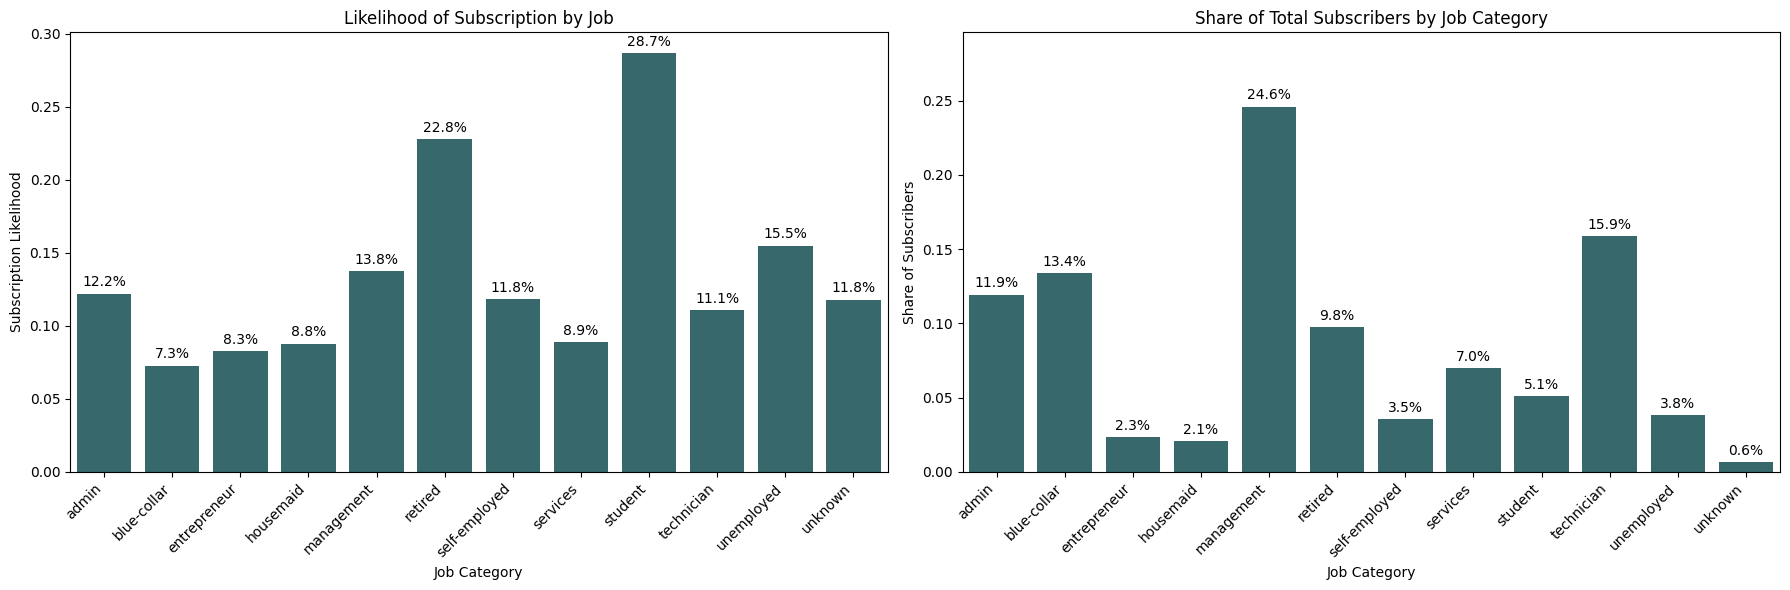

In [36]:
# Convert y to binary
df['y_binary'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

#-------------------------
# Compute likelihood
#-------------------------
likelihood = (
    df.groupby('job')['y_binary']
    .mean()
    #.sort_values(ascending=False)
)

#-------------------------
# Compute volume
#-------------------------
volume = (
    df[df['y'] == 'yes']['job']
    .value_counts(normalize=True)
    #.sort_index()
)

# create consistent order for both charts
job_order = sorted(df['job'].unique()) # or likelihood.index.tolist()
likelihood = likelihood.reindex(job_order)
volume = volume.reindex(job_order)

#-------------------------
# Side-by-side plots
#-------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#----------------------------------------
# Plot 1: Likelihood of Subscription
#----------------------------------------
ax1 = axes[0]
sns.barplot(
    x=likelihood.index,
    y=likelihood.values,
    ax=ax1,
    color="#2F6F73"
)

ax1.set_title("Likelihood of Subscription by Job")
ax1.set_xlabel("Job Category")
ax1.set_ylabel("Subscription Likelihood")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Accurate percentage labels
for i, v in enumerate(likelihood.values):
    ax1.text(i, v + 0.005, f"{v:.1%}", ha='center')

#----------------------------------------
# Plot 2: Volume of Subscribers
#----------------------------------------
ax2 = axes[1]
sns.barplot(
    x=volume.index,
    y=volume.values,
    ax=ax2,
    color="#2F6F73"
)

ax2.set_title("Share of Total Subscribers by Job Category")
ax2.set_xlabel("Job Category")
ax2.set_ylabel("Share of Subscribers")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylim(0, volume.max() + 0.05)

# Percentage labels
for i, v in enumerate(volume.values):
    ax2.text(i, v + 0.005, f"{v:.1%}", ha='center')

plt.tight_layout()
plt.show()


Yes, retired customers are more likely to subscribe than working professionals

### #Insights
> - Students and Retired customers show the highest subscription likelihood, but they represent relatively small portions of the subscriber base
> - Most subscribers come from working professional groups such as management, technician, blue-collar, and admin
>   - These groups have lower likelihood but large population size, meaning even little improvements in conversion rates could generate substantial total gains

In [ ]:
# Target Matrix with plotly to show the target segments based on subscription likelihood and subscriber volume by job category
import pandas as pd
import plotly.express as px

# --- Prepare data ---
df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)

# Likelihood table
likelihood = (
    df.groupby('job')['y_binary']
    .mean()
    .reset_index()
    .rename(columns={'y_binary': 'likelihood'})
)

# Volume table (share of all subscribers)
subscriber_counts = (
    df[df['y'] == 'yes']
    .groupby('job')
    .size()
    .reset_index(name='subscriber_count')
)

total_subscribers = subscriber_counts['subscriber_count'].sum()
subscriber_counts['volume_share'] = subscriber_counts['subscriber_count'] / total_subscribers

# Sample size table
sample_size = df.groupby('job').size().reset_index(name='sample_size')

# Merge all metrics
merged = likelihood.merge(subscriber_counts, on='job', how='left')
merged = merged.merge(sample_size, on='job', how='left')
merged['volume_share'] = merged['volume_share'].fillna(0)

# --- Compute thresholds ---
likelihood_threshold = merged['likelihood'].median()
volume_threshold = merged['volume_share'].median()

# --- Assign quadrant labels ---
def classify_quadrant(row):
    if row['volume_share'] >= volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Prime Target"
    elif row['volume_share'] >= volume_threshold and row['likelihood'] < likelihood_threshold:
        return "Improvement Opportunity"
    elif row['volume_share'] < volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Niche / Unstable"
    else:
        return "Low Priority"

merged['quadrant'] = merged.apply(classify_quadrant, axis=1)

# --- Quadrant color map ---
quadrant_colors = {
    "Prime Target":  "#1f77b4",              # blue
    "Improvement Opportunity": "#ff7f0e",  # orange
    "Niche / Unstable": "#2ca02c",          # green
    "Low Priority": "#d62728"         # red 
}

# --- Base scatter ---
fig = px.scatter(
    merged,
    x='volume_share',
    y='likelihood',
    color='quadrant',
    size='sample_size',
    hover_data={
        "job": True,
        "likelihood": ":.2%",
        "volume_share": ":.2%",
        "sample_size": True,
        "subscriber_count": True,
        "quadrant": True
    },
    title="Job Target Matrix: Subscription Likelihood vs Subscriber Volume",
    labels={'volume_share': 'Share of All Subscribers', 'likelihood': 'Subscription Likelihood'},
    size_max=55,
    color_discrete_map=quadrant_colors
)

# Add quadrant reference lines
fig.add_hline(y=likelihood_threshold, line_dash="dash", line_color="gray")
fig.add_vline(x=volume_threshold, line_dash="dash", line_color="gray")

fig.update_layout(width=900, height=650, legend_title_text="Segment Type")

# --- Quadrant labels ---
x_min, x_max = merged['volume_share'].min(), merged['volume_share'].max()
y_min, y_max = merged['likelihood'].min(), merged['likelihood'].max()
x_left  = (x_min + volume_threshold) / 2
x_right = (volume_threshold + x_max) / 2 
y_bottom = (y_min + likelihood_threshold) / 2 # not used but calculated for consistency
y_top    = (likelihood_threshold + y_max) / 2

# for improving the readability of "Improvement Opportunity" and "Low Priority" labels in the graph, we set a specific location for it
x_improve = volume_threshold + (x_max - volume_threshold) * 0.95
y_improve = y_min + (likelihood_threshold - y_min) * -1.05

fig.add_annotation(x=x_right, y=y_top, text="Prime Target", showarrow=False, font=dict(size=14, color= "#1f77b4"))
fig.add_annotation(x=x_improve, y=y_improve, text="Improvement Opportunity", showarrow=False, font=dict(size=14, color="#ff7f0e"))
fig.add_annotation(x=x_left, y=y_top, text="Niche / Unstable", showarrow=False, font=dict(size=14, color= "#2ca02c"))
fig.add_annotation(x=x_left, y=y_improve, text="Low Priority", showarrow=False, font=dict(size=14, color="#d62728"))

# --- Bubble labels ---
for _, row in merged.iterrows():

    label_text = (
        f"<b>{row['job']}</b><br>"
        f"Lik: {row['likelihood']:.1%}<br>"
        f"Vol: {row['volume_share']:.1%}"
    )

    if row['volume_share'] < volume_threshold:
        xanchor = "right"
        xshift = -10
    else:
        xanchor = "left"
        xshift = 10


    fig.add_annotation(
        x=row['volume_share'],
        y=row['likelihood'],
        text=label_text,
        showarrow=False,
        font=dict(size=11, color="black"),
        align="left",
        xanchor=xanchor,
        yanchor="middle",
        xshift=xshift,
        bgcolor="rgba(255,255,255,0.75)",
        bordercolor="rgba(0,0,0,0.25)",
        borderwidth=1,
        borderpad=3
    )
    # Add information box explaining quadrants
    fig.add_annotation(
        x=1.37, y=-0.15, xref="paper", yref="paper",
        text=(
        "Large sample + high likelihood → <b>Prime Targets</b><br>"
        "Large sample + low likelihood → <b>Improvement Opportunities</b><br>"
        "Small sample + high likelihood → <b>Niche / Unstable</b><br>"
        "Small sample + low likelihood → <b>Low Priority</b>"
        ),
        showarrow=False,
        align="left",
        font=dict(size=8, color="black"),
        bordercolor="lightgrey",
        borderwidth=1,
        borderpad=6,
        bgcolor="white",
        opacity=0.9)

fig.show()


### #Insights

* The target matrix combines likelihood and volume, which helps identify where marketing spend produces the highest ROI
    > - it uses median subscription likelihood and median subscriber volume as threshold to divide job groups into 4 quadrants
    > - ensures quadrant reflects relative performance within the dataset
* Though retired clients are not the largest job group, their subscriber volume is above the median threshold used in this matrix. Combined with their high likelihood, this places them in the Prime Target quadrant

### Question 3: Does a customer's age and job jointly infuence the probability of subscription?

C:\Users\papak\AppData\Local\Temp\ipykernel_240\259954733.py:16: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

C:\Users\papak\AppData\Local\Temp\ipykernel_240\259954733.py:24: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



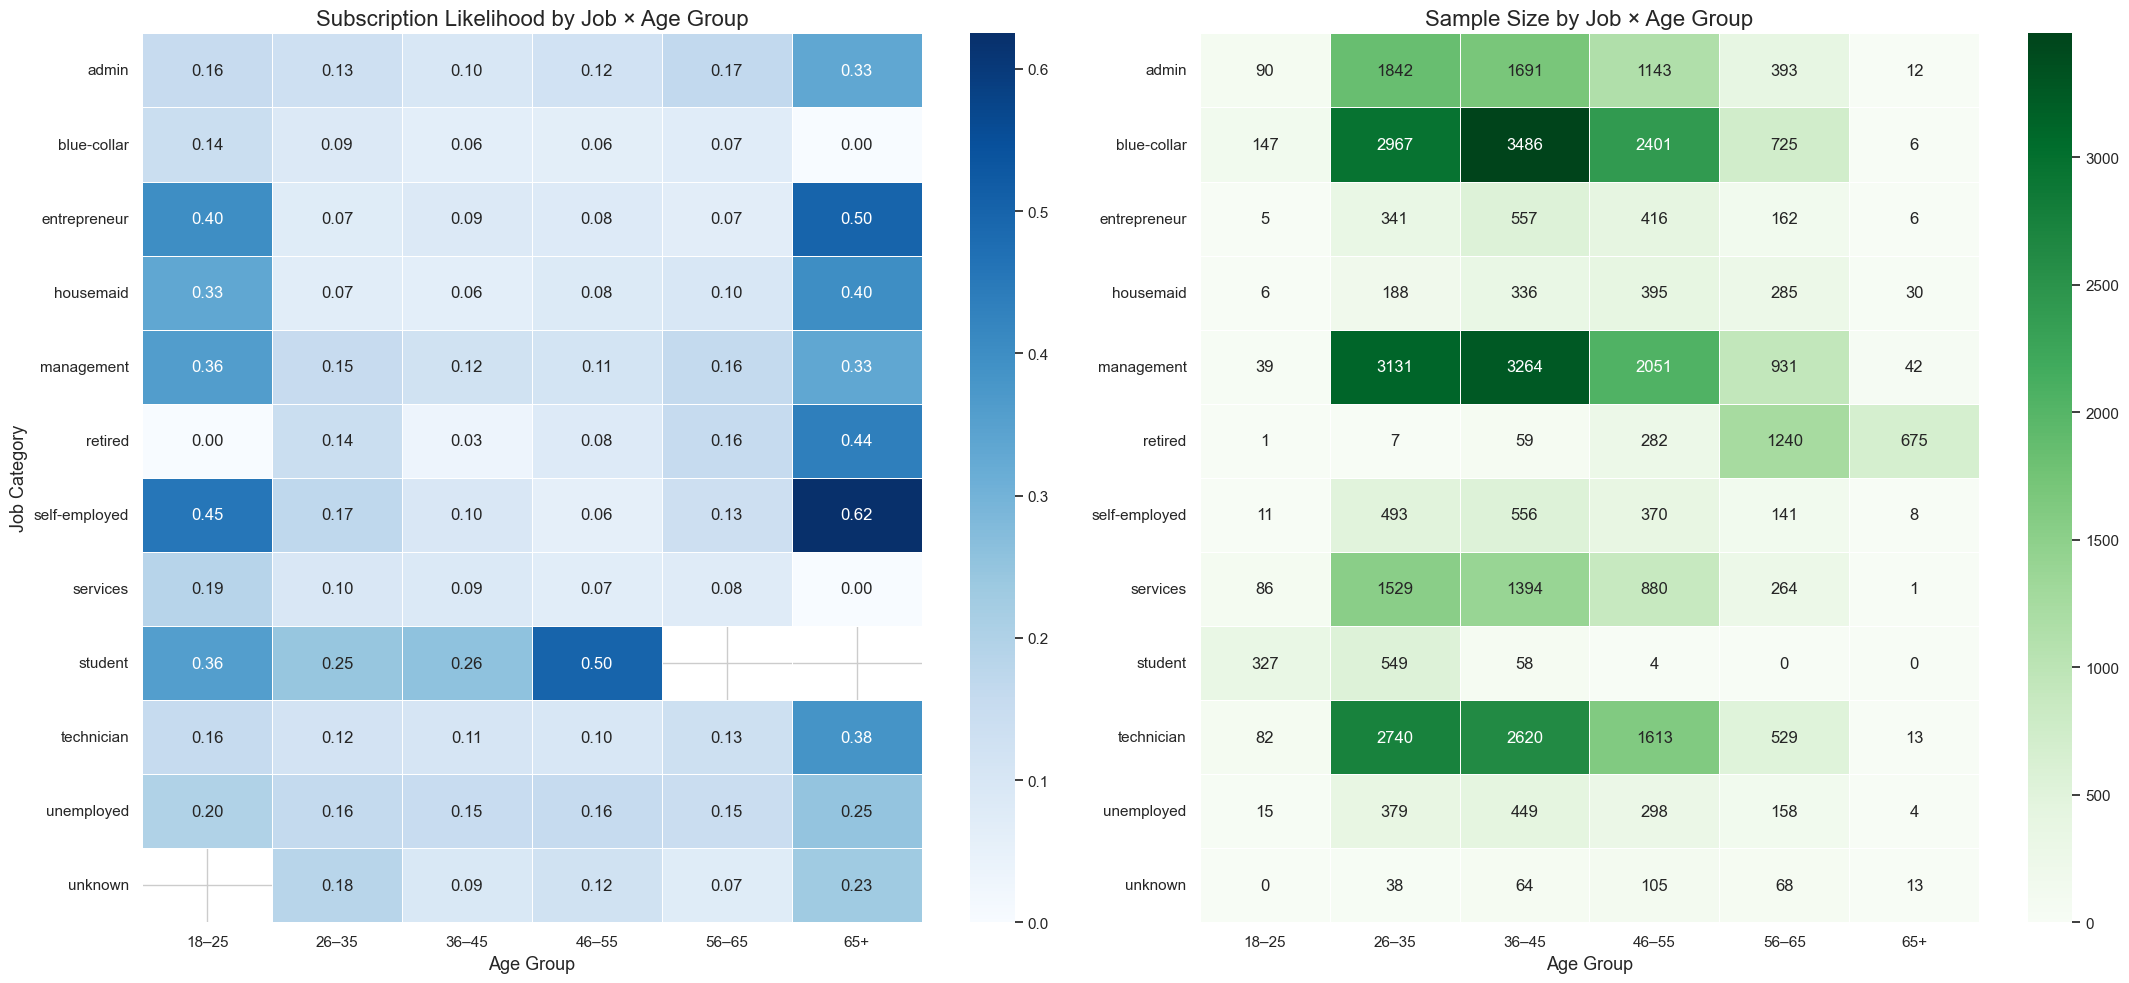

In [39]:
#-------------------------
#Dual heatmap of likelihood and volume by job and age group
#-------------------------

# --- Prepare data ---

# Age groups
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18–25', '26–35', '36–45', '46–55', '56–65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Binary target
df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)

# Likelihood table
likelihood = df.pivot_table(
    values='y_binary',
    index='job',
    columns='age_group',
    aggfunc='mean'
)

# Sample size table
sample_size = df.pivot_table(
    values='y_binary',
    index='job',
    columns='age_group',
    aggfunc='count'
)

# --- Plot dual heatmaps ---

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Likelihood heatmap
sns.heatmap(
    likelihood,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=.5,
    ax=axes[0]
)
axes[0].set_title("Subscription Likelihood by Job × Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Job Category")

# Sample size heatmap
sns.heatmap(
    sample_size,
    annot=True,
    fmt="d",
    cmap="Greens",
    linewidths=.5,
    ax=axes[1]
)
axes[1].set_title("Sample Size by Job × Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


> Summary:
- High-value segment (high likelihood + meaningful sample size):
    | Job          | Age Group      |
    |--------------|----------------|
    | Retired      | 56–65, 65+     |
    | Unemployed   | 56-65          |
    | Student      | 18–25, 26–35   |


- Improvement Opportunities (large segments but low-moderate likelihood segments):

    | Job          | Age Group                |
    |--------------|--------------------------|
    | Blue-collar  | 26–35,36–45, 46–55       |
    | Services     | 26–35,36–45, 46–55       |
    | Admin        | 26–35, 36–45             |
    | Technician   | 26–35, 36–45             |
> if conversion improved can yield largest business impact 

- High-likelihood but tiny segments (statistical noise):
    | Job          | Age Group      |
    |--------------|----------------|
    | Entrepreneur | 65+            |
    | Management   | 65+            |
    | Admin        | 65+            |
    | Technician   | 65+            |
    | Housemaid    | 65+            |
    | Student      | 46–55          |
    | Unknown      | 18–25, 65+     |
> these segments' sample size are too small to be reliable

Remarks: Stability thresholds used:
* n < 20 → statistical noise (ignore)
* 20 ≤ n < 50 → unstable but usable with caution
* n ≥ 50 → reasonably stable
* n ≥ 200 → very stable and reliable

> Conclusion:
> The heatmap shows that job and age interact strongly in shaping subscription likelihood
> - older retired customers
> - younger students
> - mid-older unemployed customers


> Working-age groups (26-35, 36-45, 45-55) such as Blue-collar, Services, Admin and Technician remain low likelihood, making them the best candidate for conversion-rate improvement

In [ ]:
#-------------------------
# Interactive scatter plot of likelihood vs sample size by job and age group
#-------------------------

import plotly.express as px

# Age groups
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18–25', '26–35', '36–45', '46–55', '56–65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Binary target
df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)

# Likelihood table
likelihood = df.pivot_table(
    values='y_binary',
    index='job',
    columns='age_group',
    aggfunc='mean'
)

# Sample size table
sample_size = df.pivot_table(
    values='y',
    index='job',
    columns='age_group',
    aggfunc='count',
    fill_value=0
)

# Melt both tables into long format
likelihood_long = likelihood.reset_index().melt(id_vars='job', var_name='age_group', value_name='likelihood')
sample_long = sample_size.reset_index().melt(id_vars='job', var_name='age_group', value_name='sample_size')

# Merge likelihood + sample size
merged = pd.merge(likelihood_long, sample_long, on=['job', 'age_group'])

# Remove rows with missing likelihood
merged = merged.dropna(subset=['likelihood'])

# --- Compute thresholds ---
likelihood_threshold = merged['likelihood'].median()
sample_threshold = merged['sample_size'].median()

# --- Assign quadrant labels ---
def classify_quadrant(row):
    if row['sample_size'] >= sample_threshold and row['likelihood'] >= likelihood_threshold:
        return "Prime Target"
    elif row['sample_size'] >= sample_threshold and row['likelihood'] < likelihood_threshold:
        return "Improvement Opportunity"
    elif row['sample_size'] < sample_threshold and row['likelihood'] >= likelihood_threshold:
        return "Niche / Unstable"
    else:
        return "Low Priority"

merged['quadrant'] = merged.apply(classify_quadrant, axis=1)


# --- Interactive scatter plot ---
fig = px.scatter(
    merged,
    x='sample_size',
    y='likelihood',
    color='quadrant',
    size='sample_size',
    hover_name='job',
    hover_data={
        'age_group': True,
        'sample_size': True,
        'likelihood': ':.2f',
        'quadrant': True
    },
    title="Interactive Target Matrix: Subscription Likelihood vs Sample Size (Job × Age Group)",
    labels={
        'sample_size': 'Sample Size (Segment Size)',
        'likelihood': 'Subscription Likelihood'
    },
    size_max=40,
    color_discrete_map={
        "Prime Target": "#1f77b4",              # blue
        "Improvement Opportunity": "#ff7f0e",   # orange
        "Niche / Unstable": "#2ca02c",          # green
        "Low Priority": "#d62728"               # red
    }
)

# Add quadrant reference lines
fig.add_hline(y=likelihood_threshold, line_dash="dash", line_color="gray")
fig.add_vline(x=sample_threshold, line_dash="dash", line_color="gray")

fig.update_layout(
    width=1000,
    height=700,
    legend_title_text="Segment Type"
)

# --- Compute quadrant midpoints for centered labels ---
x_min, x_max = merged['sample_size'].min(), merged['sample_size'].max()
y_min, y_max = merged['likelihood'].min(), merged['likelihood'].max()

x_left  = (x_min + sample_threshold) / 2
x_right = (sample_threshold + x_max) / 2
y_bottom = (y_min + likelihood_threshold) / 2
y_top    = (likelihood_threshold + y_max) / 2

# --- Add quadrant shading (background rectangles) ---
fig.add_shape(type="rect",
              x0=x_min, x1=sample_threshold,
              y0=y_min, y1=likelihood_threshold,
              fillcolor="rgba(214, 39, 40, 0.08)", line_width=0)

fig.add_shape(type="rect",
              x0=sample_threshold, x1=x_max,
              y0=y_min, y1=likelihood_threshold,
              fillcolor="rgba(255, 127, 14, 0.08)", line_width=0)

fig.add_shape(type="rect",
              x0=x_min, x1=sample_threshold,
              y0=likelihood_threshold, y1=y_max,
              fillcolor="rgba(44, 160, 44, 0.08)", line_width=0)

fig.add_shape(type="rect",
              x0=sample_threshold, x1=x_max,
              y0=likelihood_threshold, y1=y_max,
              fillcolor="rgba(31, 119, 180, 0.08)", line_width=0)

# --- Add centered quadrant labels ---
fig.add_annotation(
    x=x_right, y=y_top,
    text="Prime Target", #if want incorporate the quadrant explanation lable still have space for this graph, add code after: <br>High likelihood & Large sample",
    showarrow=False, font=dict(size=13)
)

fig.add_annotation(
    x=x_right, y=y_bottom,
    text="Improvement Opportunity", # add code: <br>Low likelihood & Large sample",
    showarrow=False, font=dict(size=13)
)

fig.add_annotation(
    x=x_left, y=y_top,
    text="Niche / Unstable", # add code: <br>High likelihood & Small sample",
    showarrow=False, font=dict(size=13)
)

fig.add_annotation(
    x=x_left, y=y_bottom,
    text="Low Priority", # add code: <br>Low likelihood & Small sample",
    showarrow=False, font=dict(size=13)
)

# Add information box explaining quadrants
fig.add_annotation(
    x=1.32, y=-0.15, xref="paper", yref="paper",
    text=(
    "Large sample + high likelihood → <b>Prime Targets</b><br>"
    "Large sample + low likelihood → <b>Improvement Opportunities</b><br>"
    "Small sample + high likelihood → <b>Niche / Unstable</b><br>"
    "Small sample + low likelihood → <b>Low Priority</b>"
    ),
    showarrow=False,
    align="left",
    font=dict(size=8, color="black"),
    bordercolor="lightgrey",
    borderwidth=1,
    borderpad=6,
    bgcolor="white",
    opacity=0.9)

fig.show()


C:\Users\papak\AppData\Local\Temp\ipykernel_240\544610328.py:16: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

C:\Users\papak\AppData\Local\Temp\ipykernel_240\544610328.py:24: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



### #Insights

> - While the heatmap shows patterns visually, the target matrix uses actual numbers and cut-off rules, it therefore picks up more (every) segments for each quadrants
> - The target matrix gives a more systematic, rule-based classification

### Question 4: Does a customer's education level impact subscription?

/var/folders/m9/3qw5qv8x7bdb20d_n3wnbqpm0000gn/T/ipykernel_50676/152389590.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/m9/3qw5qv8x7bdb20d_n3wnbqpm0000gn/T/ipykernel_50676/152389590.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
/var/folders/m9/3qw5qv8x7bdb20d_n3wnbqpm0000gn/T/ipykernel_50676/152389590.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


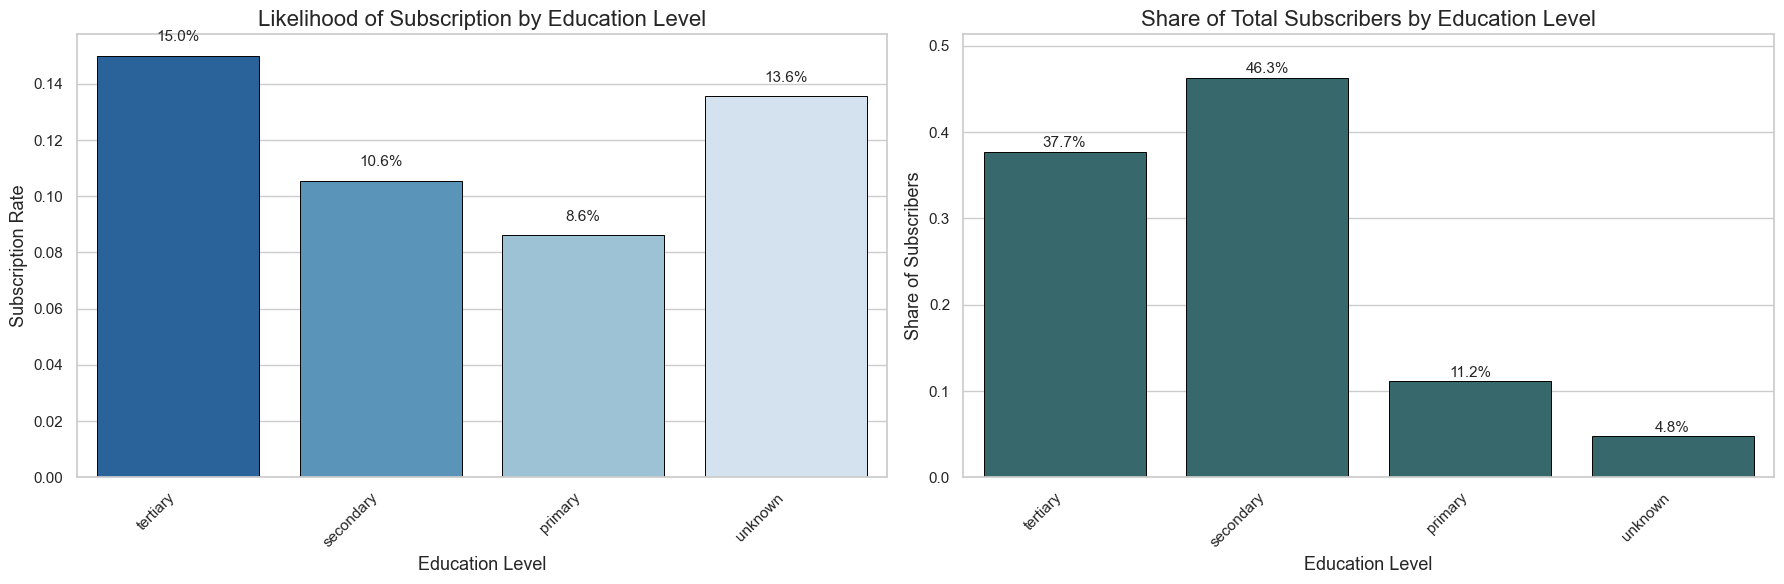

In [42]:
# Convert y to binary
df['y_binary'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Define desired order for the charts
edu_order = ["tertiary", "secondary", "primary", "unknown"]

# Convert to ordered categorical
df['education'] = pd.Categorical(df['education'], categories=edu_order, ordered=True)


#-------------------------
# Compute likelihood
#-------------------------
edu_likelihood = (
    df.groupby('education')['y_binary']
    .mean()
    .reindex(edu_order)
    #.sort_values(ascending=False)
)

#-------------------------
# Compute volume
#-------------------------
edu_volume = (
    df[df['y'] == 'yes']['education']
    .value_counts(normalize=True)
    #.sort_index()
    .reindex(edu_order)
)


#-------------------------
# Styling
#-------------------------
sns.set_theme(style="whitegrid")
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

#-------------------------
# Side-by-side plots
#-------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#----------------------------------------
# Plot 1: Likelihood of Subscription
#----------------------------------------
ax1 = axes[0]
sns.barplot(
    x=edu_likelihood.index,
    y=edu_likelihood.values,
    ax=ax1,
    palette="Blues_r",
    edgecolor="black",
    linewidth=0.7
)

ax1.set_title("Likelihood of Subscription by Education Level")
ax1.set_xlabel("Education Level")
ax1.set_ylabel("Subscription Rate")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Percentage labels
for i, v in enumerate(edu_likelihood.values):
    ax1.text(i, v + 0.005, f"{v:.1%}", ha='center', fontsize=11)

#----------------------------------------
# Plot 2: Volume of Subscribers
#----------------------------------------
ax2 = axes[1]
sns.barplot(
    x=edu_volume.index,
    y=edu_volume.values,
    ax=ax2,
    color="#2F6F73",
    edgecolor="black",
    linewidth=0.7
)

ax2.set_title("Share of Total Subscribers by Education Level")
ax2.set_xlabel("Education Level")
ax2.set_ylabel("Share of Subscribers")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylim(0, edu_volume.max() + 0.05)

# Percentage labels
for i, v in enumerate(edu_volume.values):
    ax2.text(i, v + 0.005, f"{v:.1%}", ha='center', fontsize=11)

plt.tight_layout()
plt.show()


### #Insights

> Education level does impact subscription behaviour:
> - Higher-educated customers are more responsive and show higher likelihood of subscribing
    > - Secondary-educated customers dominate total subscriber volume

In [ ]:
import pandas as pd
import plotly.express as px

# --- Prepare data ---

df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)

likelihood = df.groupby('education')['y_binary'].mean().reset_index()
likelihood.rename(columns={'y_binary': 'likelihood'}, inplace=True)

subscriber_counts = df[df['y'] == 'yes'].groupby('education').size().reset_index(name='subscriber_count')
total_subscribers = subscriber_counts['subscriber_count'].sum()
subscriber_counts['volume_share'] = subscriber_counts['subscriber_count'] / total_subscribers

merged = pd.merge(likelihood, subscriber_counts, on='education', how='left')
merged['volume_share'] = merged['volume_share'].fillna(0)

# --- Thresholds ---
likelihood_threshold = merged['likelihood'].median()
volume_threshold = merged['volume_share'].median()

# --- Quadrants ---
def classify_quadrant(row):
    if row['volume_share'] >= volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Prime Target"
    elif row['volume_share'] >= volume_threshold and row['likelihood'] < likelihood_threshold:
        return "Improvement Opportunity"
    elif row['volume_share'] < volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Niche / Unstable"
    else:
        return "Low Priority"

merged['quadrant'] = merged.apply(classify_quadrant, axis=1)

# --- Base scatter ---
fig = px.scatter(
    merged,
    x='volume_share',
    y='likelihood',
    color='quadrant',
    size='volume_share',
    hover_data={},  # disable hover
    title="Education Target Matrix: Subscription Likelihood vs Subscriber Volume",
    labels={'volume_share': 'Share of All Subscribers', 'likelihood': 'Subscription Likelihood'},
    size_max=40,
    color_discrete_map={
        "Prime Target": "#1f77b4",
        "Improvement Opportunity": "#ff7f0e",
        "Niche / Unstable": "#2ca02c",
        "Low Priority": "#d62728"
    }
)

fig.add_hline(y=likelihood_threshold, line_dash="dash", line_color="gray")
fig.add_vline(x=volume_threshold, line_dash="dash", line_color="gray")

fig.update_layout(width=900, height=650, legend_title_text="Segment Type")

# --- Quadrant shading ---
x_min, x_max = merged['volume_share'].min(), merged['volume_share'].max()
y_min, y_max = merged['likelihood'].min(), merged['likelihood'].max()

fig.add_shape(type="rect", x0=x_min, x1=volume_threshold, y0=y_min, y1=likelihood_threshold,
              fillcolor="rgba(214, 39, 40, 0.08)", line_width=0)
fig.add_shape(type="rect", x0=volume_threshold, x1=x_max, y0=y_min, y1=likelihood_threshold,
              fillcolor="rgba(255, 127, 14, 0.08)", line_width=0)
fig.add_shape(type="rect", x0=x_min, x1=volume_threshold, y0=likelihood_threshold, y1=y_max,
              fillcolor="rgba(44, 160, 44, 0.08)", line_width=0)
fig.add_shape(type="rect", x0=volume_threshold, x1=x_max, y0=likelihood_threshold, y1=y_max,
              fillcolor="rgba(31, 119, 180, 0.08)", line_width=0)

# --- Quadrant labels ---
x_left  = (x_min + volume_threshold) / 2
x_right = (volume_threshold + x_max) / 2
y_bottom = (y_min + likelihood_threshold) / 2
y_top    = (likelihood_threshold + y_max) / 2

fig.add_annotation(x=x_right, y=y_top, text="Prime Target", showarrow=False, font=dict(size=14))
fig.add_annotation(x=x_right, y=y_bottom, text="Improvement Opportunity", showarrow=False, font=dict(size=14))
fig.add_annotation(x=x_left, y=y_top, text="Niche / Unstable", showarrow=False, font=dict(size=14))
fig.add_annotation(x=x_left, y=y_bottom, text="Low Priority", showarrow=False, font=dict(size=14))

# --- Improved bubble labels ---
for _, row in merged.iterrows():

    # Bold education name + short metrics
    label_text = (
        f"<b>{row['education']}</b><br>"
        f"Lik: {row['likelihood']:.2f} | Vol: {row['volume_share']:.2f}"
    )

    # Smart label placement: right side for left quadrants, left side for right quadrants
    if row['volume_share'] < volume_threshold:
        xanchor = "right"
        xshift = -10
    else:
        xanchor = "left"
        xshift = 10

    fig.add_annotation(
        x=row['volume_share'],
        y=row['likelihood'],
        text=label_text,
        showarrow=False,
        font=dict(size=11, color="black"),
        align="left",
        xanchor=xanchor,
        yanchor="middle",
        xshift=xshift,
        bgcolor="rgba(255,255,255,0.7)",  # readable background
        bordercolor="rgba(0,0,0,0.2)",
        borderwidth=1,
        borderpad=3
    )
    fig.add_annotation(
        x=1.37, y=-0.15, xref="paper", yref="paper",
        text=(
        "Large sample + high likelihood → <b>Prime Targets</b><br>"
        "Large sample + low likelihood → <b>Improvement Opportunities</b><br>"
        "Small sample + high likelihood → <b>Niche / Unstable</b><br>"
        "Small sample + low likelihood → <b>Low Priority</b>"
        ),
        showarrow=False,
        align="left",
        font=dict(size=8, color="black"),
        bordercolor="lightgrey",
        borderwidth=1,
        borderpad=6,
        bgcolor="white",
        opacity=0.9)

fig.show()


C:\Users\papak\AppData\Local\Temp\ipykernel_240\2097493687.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\papak\AppData\Local\Temp\ipykernel_240\2097493687.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



### Question 5: How does marital status impact subscription behavior?

/var/folders/m9/3qw5qv8x7bdb20d_n3wnbqpm0000gn/T/ipykernel_50676/1070766787.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/m9/3qw5qv8x7bdb20d_n3wnbqpm0000gn/T/ipykernel_50676/1070766787.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
/var/folders/m9/3qw5qv8x7bdb20d_n3wnbqpm0000gn/T/ipykernel_50676/1070766787.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


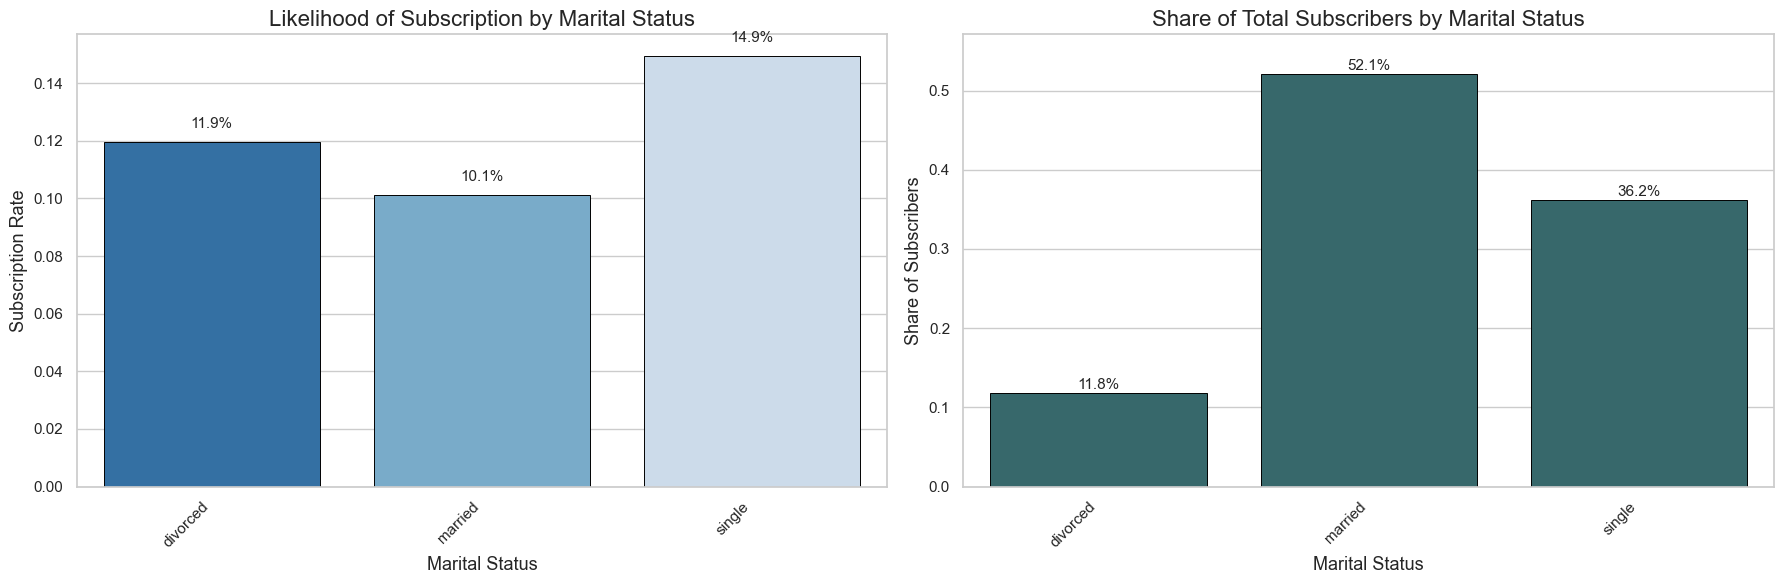

In [44]:
# Convert y to binary (if not already done)
df['y_binary'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

#-------------------------
# Compute likelihood
#-------------------------
marital_likelihood = (
    df.groupby('marital')['y_binary']
    .mean()
    #.sort_values(ascending=False)
)

#-------------------------
# Compute volume
#-------------------------
marital_volume = (
    df[df['y'] == 'yes']['marital']
    .value_counts(normalize=True)
    #.sort_index()
)

# create consistent order for both charts
marital_order = sorted(df['marital'].unique()) # or marital_likelihood.index.tolist
marital_likelihood = marital_likelihood.reindex(marital_order)
marital_volume = marital_volume.reindex(marital_order)


#-------------------------
# Styling
#-------------------------
sns.set_theme(style="whitegrid")
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

#-------------------------
# Side-by-side plots
#-------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#----------------------------------------
# Plot 1: Likelihood of Subscription
#----------------------------------------
ax1 = axes[0]
sns.barplot(
    x=marital_likelihood.index,
    y=marital_likelihood.values,
    ax=ax1,
    palette="Blues_r",
    edgecolor="black",
    linewidth=0.7
)

ax1.set_title("Likelihood of Subscription by Marital Status")
ax1.set_xlabel("Marital Status")
ax1.set_ylabel("Subscription Rate")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Percentage labels
for i, v in enumerate(marital_likelihood.values):
    ax1.text(i, v + 0.005, f"{v:.1%}", ha='center', fontsize=11)

#----------------------------------------
# Plot 2: Volume of Subscribers
#----------------------------------------
ax2 = axes[1]
sns.barplot(
    x=marital_volume.index,
    y=marital_volume.values,
    ax=ax2,
    color="#2F6F73",
    edgecolor="black",
    linewidth=0.7
)

ax2.set_title("Share of Total Subscribers by Marital Status")
ax2.set_xlabel("Marital Status")
ax2.set_ylabel("Share of Subscribers")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylim(0, marital_volume.max() + 0.05)

# Percentage labels
for i, v in enumerate(marital_volume.values):
    ax2.text(i, v + 0.005, f"{v:.1%}", ha='center', fontsize=11)

plt.tight_layout()
plt.show()


### #Insights

> Martial status does influence subscription behavior:
>    - Singles are more responsive
>    - but married customers drive the majority of total subscriptions because they are the largest group

In [ ]:
import pandas as pd 
import plotly.express as px 
# --- Prepare data ---
df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)
# Likelihood table
likelihood = df.groupby('marital')['y_binary'].mean().reset_index()
likelihood.rename(columns={'y_binary': 'likelihood'}, inplace=True)

# Volume table (share of all subscribers)
subscriber_counts = df[df['y'] == 'yes'].groupby('marital').size().reset_index(name='subscriber_count')
total_subscribers = subscriber_counts['subscriber_count'].sum()
subscriber_counts['volume_share'] = subscriber_counts['subscriber_count'] / total_subscribers

# Merge likelihood + volume
merged = pd.merge(likelihood, subscriber_counts, on='marital', how='left')
merged['volume_share'] = merged['volume_share'].fillna(0)

# --- Compute thresholds ---
likelihood_threshold = merged['likelihood'].median()
volume_threshold = merged['volume_share'].median()

# --- Assign quadrant labels ---
def classify_quadrant(row):
    if row['volume_share'] >= volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Prime Target"
    elif row['volume_share'] >= volume_threshold and row['likelihood'] < likelihood_threshold:
        return "Improvement Opportunity"
    elif row['volume_share'] < volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Niche / Unstable"
    else:
        return "Low Priority"

merged['quadrant'] = merged.apply(classify_quadrant, axis=1)

# --- Base scatter ---
fig = px.scatter(
    merged,
    x='volume_share',
    y='likelihood',
    color='quadrant',
    size='volume_share',
    hover_data={},  # disable hover
    title="Marital Status Target Matrix: Subscription Likelihood vs Subscriber Volume",
    labels={'volume_share': 'Share of All Subscribers', 'likelihood': 'Subscription Likelihood'},
    size_max=40,
    color_discrete_map={
        "Prime Target": "#1f77b4",
        "Improvement Opportunity": "#ff7f0e",
        "Niche / Unstable": "#2ca02c",
        "Low Priority": "#d62728"
    }
)

# Add quadrant reference lines
fig.add_hline(y=likelihood_threshold, line_dash="dash", line_color="gray")
fig.add_vline(x=volume_threshold, line_dash="dash", line_color="gray")

fig.update_layout(width=900, height=650, legend_title_text="Segment Type")

# --- Quadrant shading ---
x_min, x_max = merged['volume_share'].min(), merged['volume_share'].max()
y_min, y_max = merged['likelihood'].min(), merged['likelihood'].max()

fig.add_shape(type="rect", x0=x_min, x1=volume_threshold, y0=y_min, y1=likelihood_threshold,
              fillcolor="rgba(214, 39, 40, 0.08)", line_width=0)
fig.add_shape(type="rect", x0=volume_threshold, x1=x_max, y0=y_min, y1=likelihood_threshold,
              fillcolor="rgba(255, 127, 14, 0.08)", line_width=0)
fig.add_shape(type="rect", x0=x_min, x1=volume_threshold, y0=likelihood_threshold, y1=y_max,
              fillcolor="rgba(44, 160, 44, 0.08)", line_width=0)
fig.add_shape(type="rect", x0=volume_threshold, x1=x_max, y0=likelihood_threshold, y1=y_max,
              fillcolor="rgba(31, 119, 180, 0.08)", line_width=0)

# --- Quadrant labels ---
x_left  = (x_min + volume_threshold) / 2
x_right = (volume_threshold + x_max) / 2
y_bottom = (y_min + likelihood_threshold) / 2
y_top    = (likelihood_threshold + y_max) / 2

fig.add_annotation(x=x_right, y=y_top, text="Prime Target", showarrow=False, font=dict(size=14))
fig.add_annotation(x=x_right, y=y_bottom, text="Improvement Opportunity", showarrow=False, font=dict(size=14))
fig.add_annotation(x=x_left, y=y_top, text="Niche / Unstable", showarrow=False, font=dict(size=14))
fig.add_annotation(x=x_left, y=y_bottom, text="Low Priority", showarrow=False, font=dict(size=14))

# --- Improved bubble labels ---
for _, row in merged.iterrows():

    label_text = (
        f"<b>{row['marital']}</b><br>"
        f"Lik: {row['likelihood']:.2f} | Vol: {row['volume_share']:.2f}"
    )

    # Smart label placement
    if row['volume_share'] < volume_threshold:
        xanchor = "right"
        xshift = -10
    else:
        xanchor = "left"
        xshift = 10

    fig.add_annotation(
        x=row['volume_share'],
        y=row['likelihood'],
        text=label_text,
        showarrow=False,
        font=dict(size=11, color="black"),
        align="left",
        xanchor=xanchor,
        yanchor="middle",
        xshift=xshift,
        bgcolor="rgba(255,255,255,0.75)",
        bordercolor="rgba(0,0,0,0.25)",
        borderwidth=1,
        borderpad=3
    )
    # Add information box explaining quadrants
    fig.add_annotation(
        x=1.37, y=-0.15, xref="paper", yref="paper",
        text=(
        "Large sample + high likelihood → <b>Prime Targets</b><br>"
        "Large sample + low likelihood → <b>Improvement Opportunities</b><br>"
        "Small sample + high likelihood → <b>Niche / Unstable</b><br>"
        "Small sample + low likelihood → <b>Low Priority</b>"
        ),
        showarrow=False,
        align="left",
        font=dict(size=8, color="black"),
        bordercolor="lightgrey",
        borderwidth=1,
        borderpad=6,
        bgcolor="white",
        opacity=0.9)

fig.show()

# Export PNG (requires Kaleido installed)
# fig.write_image("marital_target_matrix.png")


### #Insights

> Divorced customers fall on the boundary between Niche and Low Priority, meaning their subscription rate is neither high enough to be considered a strong responder nor low enough to be considered weak. Along with their subscriber volume is also moderate, so they don't show a strong strategic signal

### Additional Summary: 4-factor demographic summary chart

In [ ]:
import pandas as pd
import numpy as np

# --- Prepare data ---

# Age groups
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18–25', '26–35', '36–45', '46–55', '56–65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Binary target
df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)

# Group by all 4 demographic factors
segment = df.groupby(['age_group', 'job', 'education', 'marital']).agg(
    likelihood=('y_binary', 'mean'),
    volume=('y_binary', 'sum'),
    sample_size=('y_binary', 'count')
).reset_index()

# Remove tiny segments (unstable)
segment = segment[segment['sample_size'] >= 50]

# Priority score = likelihood × log(sample size)
segment['priority_score'] = segment['likelihood'] * np.log(segment['sample_size'] + 1)

# --- Quadrant thresholds ---
likelihood_threshold = segment['likelihood'].median()
sample_threshold = segment['sample_size'].median()

# --- Assign quadrant labels ---
def classify_quadrant(row):
    if row['sample_size'] >= sample_threshold and row['likelihood'] >= likelihood_threshold:
        return "Prime Target"
    elif row['sample_size'] >= sample_threshold and row['likelihood'] < likelihood_threshold:
        return "Improvement Opportunity"
    elif row['sample_size'] < sample_threshold and row['likelihood'] >= likelihood_threshold:
        return "Niche / Unstable"
    else:
        return "Low Priority"

segment['quadrant'] = segment.apply(classify_quadrant, axis=1)

# --- Sort segments within each quadrant ---
segment_sorted = segment.sort_values(
    by=['quadrant', 'priority_score'], ascending=[True, False]
)

# --- Create separate tables for each quadrant ---
prime_target = segment_sorted[segment_sorted['quadrant'] == "Prime Target"]
improvement = segment_sorted[segment_sorted['quadrant'] == "Improvement Opportunity"]
niche = segment_sorted[segment_sorted['quadrant'] == "Niche / Unstable"]
low_priority = segment_sorted[segment_sorted['quadrant'] == "Low Priority"]

# --- Optional: create a single combined table for export ---
summary_table = segment_sorted[[
    'quadrant', 'age_group', 'job', 'education', 'marital',
    'likelihood', 'sample_size', 'priority_score'
]]

summary_table


C:\Users\papak\AppData\Local\Temp\ipykernel_240\3687521816.py:15: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,quadrant,age_group,job,education,marital,likelihood,sample_size,priority_score
544,Improvement Opportunity,46–55,technician,secondary,married,0.104750,821,0.703057
148,Improvement Opportunity,26–35,admin,secondary,married,0.106489,601,0.681558
293,Improvement Opportunity,36–45,admin,secondary,single,0.104326,393,0.623487
256,Improvement Opportunity,26–35,technician,secondary,married,0.094752,686,0.618953
253,Improvement Opportunity,26–35,technician,tertiary,married,0.106164,292,0.603032
...,...,...,...,...,...,...,...,...
435,Prime Target,46–55,admin,secondary,divorced,0.121359,206,0.647175
480,Prime Target,46–55,management,tertiary,divorced,0.112540,311,0.646319
519,Prime Target,46–55,services,secondary,divorced,0.125000,128,0.607477
450,Prime Target,46–55,blue-collar,primary,divorced,0.121429,140,0.600921


In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. QUADRANT BUBBLE CHART (Likelihood vs Sample Size)
# ---------------------------------------------------------

fig1 = px.scatter(
    segment,
    x="sample_size",
    y="likelihood",
    size="volume",
    color="quadrant",
    hover_data=["age_group", "job", "education", "marital", "priority_score"],
    title="Quadrant Bubble Chart: Likelihood vs Sample Size",
    labels={"sample_size": "Sample Size", "likelihood": "Subscription Likelihood"},
    size_max=40
)

fig1.update_layout(
    plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="lightgrey"),
    yaxis=dict(showgrid=True, gridcolor="lightgrey")
)

# Add information box explaining quadrants
fig1.add_annotation(
    x=1.35, y=-0.20, xref="paper", yref="paper",
    text=(
        "Large sample + high likelihood → <b>Prime Targets</b><br>"
        "Large sample + low likelihood → <b>Improvement Opportunities</b><br>"
        "Small sample + high likelihood → <b>Niche / Unstable</b><br>"
        "Small sample + low likelihood → <b>Low Priority</b>"
    ),
    showarrow=False,
    align="left",
    font=dict(size=12, color="black"),
    bordercolor="lightgrey",
    borderwidth=1,
    borderpad=6,
    bgcolor="white",
    opacity=0.9
)


fig1.show()


# ---------------------------------------------------------
# 2. TREEMAP (Population Structure by 4 Demographics)
# ---------------------------------------------------------

fig2 = px.treemap(
    segment,
    path=["age_group", "job", "education", "marital"],
    values="sample_size",
    color="likelihood",
    color_continuous_scale="Blues",
    title="Treemap: Population Structure by Demographic Layers"
)

fig2.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig2.show()


# ---------------------------------------------------------
# 3. HEATMAPS (Pairwise Interactions)
# ---------------------------------------------------------

# Age × Job likelihood heatmap
heat_age_job = segment.groupby(["age_group", "job"])["likelihood"].mean().reset_index()
pivot_age_job = heat_age_job.pivot(index="age_group", columns="job", values="likelihood")

fig3 = px.imshow(
    pivot_age_job,
    color_continuous_scale="Viridis",
    title="Heatmap: Likelihood by Age Group × Job",
    labels=dict(color="Likelihood")
)

fig3.update_layout(xaxis=dict(side="top"))
fig3.show()


# Education × Job likelihood heatmap
heat_edu_job = segment.groupby(["education", "job"])["likelihood"].mean().reset_index()
pivot_edu_job = heat_edu_job.pivot(index="education", columns="job", values="likelihood")

fig4 = px.imshow(
    pivot_edu_job,
    color_continuous_scale="Viridis",
    title="Heatmap: Likelihood by Education × Job",
    labels=dict(color="Likelihood")
)

fig4.update_layout(xaxis=dict(side="top"))
fig4.show()


# ---------------------------------------------------------
# 4. TOP PRIME TARGET SEGMENTS (Ranked Bar Chart)
# ---------------------------------------------------------

top_prime = (
    segment[segment["quadrant"] == "Prime Target"]
    .sort_values("priority_score", ascending=False)
    .head(12)
)

top_prime["segment_label"] = (
    top_prime["age_group"].astype(str) + " | " +
    top_prime["job"].astype(str) + " | " +
    top_prime["education"].astype(str) + " | " +
    top_prime["marital"].astype(str)
)

fig5 = px.bar(
    top_prime,
    x="priority_score",
    y="segment_label",
    color="likelihood",
    orientation="h",
    color_continuous_scale="Greens",
    title="Top Prime Target Segments (Ranked by Priority Score)",
    labels={"priority_score": "Priority Score", "segment_label": "Segment"}
)

fig5.update_layout(yaxis=dict(categoryorder="total ascending"))

fig5.add_annotation(
    x=1, y=0, xref="paper", yref="paper",
    text=(
        "<b>Priority Score Formula</b><br>"
        "Likelihood × log(sample size + 1)<br><br>"
        "<b>Factors considered:</b><br>"
        "• Subscription likelihood<br>"
        "• Segment sample size<br>"
        "*Higher for segments with both responsive and large"
    ),
    showarrow=False,
    align="left",
    font=dict(size=12, color="black"),
    bordercolor="lightgrey",
    borderwidth=1,
    borderpad=6,
    bgcolor="white",
    opacity=0.9
)


fig5.show()

# Remarks:
# Volume affects likelihood --> affect priority score
# Sample size affect log term --> affect priority score
# Log term <> the reason volume is included


C:\Users\papak\AppData\Local\Temp\ipykernel_240\4018718707.py:73: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



C:\Users\papak\AppData\Local\Temp\ipykernel_240\4018718707.py:88: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



# Financial Profile 

### Question 1:  Does higher account balance increase likelihood of subscription?

In [ ]:
import os
print("Current working directory:", os.getcwd())

Current working directory: c:\Users\mjars\Documents\Learning\DSI\ds_team2_bank_marketing\notebooks


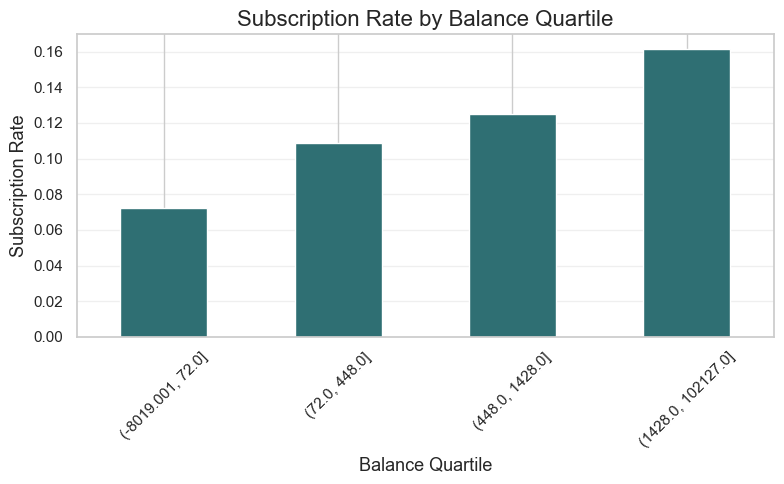

In [76]:

import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Create balance quartiles
df["balance_bin"] = pd.qcut(df["balance"], q=4, duplicates="drop")

# 4) Calculate subscription rate per quartile
conversion_by_bin = df.groupby("balance_bin")["subscribed"].mean()

# 5) Plot bar chart
plt.figure(figsize=(8, 5))
conversion_by_bin.plot(kind="bar", color = '#2F6F73')

plt.title("Subscription Rate by Balance Quartile")
plt.xlabel("Balance Quartile")
plt.ylabel("Subscription Rate")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()


plt.show()

### #Insight
- Higher-balance customers show higher subscription rates.
- Targeting high-balance segments may improve campaign efficiency.

### Question 2: Does having a housing loan affect subscription probability? 

Subscription rate by housing loan status:
housing
no     0.167024
yes    0.077000
Name: subscribed, dtype: float64


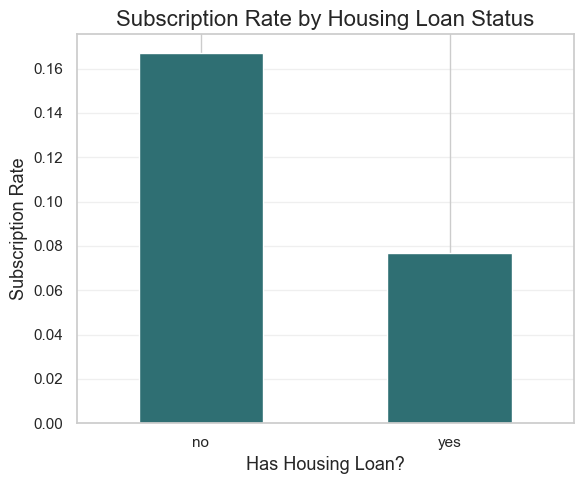

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset 
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert subscription target to numeric (1 = yes, 0 = no)
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Calculate subscription rate grouped by housing loan status
housing_conversion = df.groupby("housing")["subscribed"].mean()

print("Subscription rate by housing loan status:")
print(housing_conversion)

# 4) Create bar chart
plt.figure(figsize=(6, 5))
housing_conversion.plot(kind="bar",color = '#2F6F73')

plt.title("Subscription Rate by Housing Loan Status")
plt.xlabel("Has Housing Loan?")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### #Insight
- Customers with housing loans have lower subscription rates.
- Housing loan status may help refine customer targeting.

### Question 3: Does having a personal loan affect subscription behavior?

Subscription rate by personal loan status:
loan
no     0.126557
yes    0.066814
Name: subscribed, dtype: float64


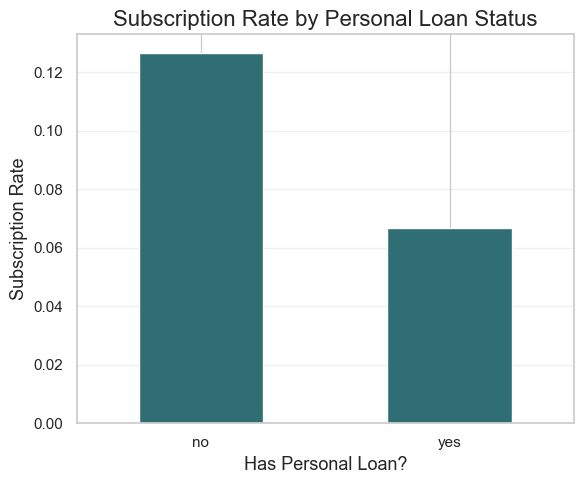

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Calculate subscription rate by personal loan status
loan_conversion = df.groupby("loan")["subscribed"].mean()

print("Subscription rate by personal loan status:")
print(loan_conversion)

# 4) Create bar chart
plt.figure(figsize=(6, 5))
loan_conversion.plot(kind="bar", color = '#2F6F73')

plt.title("Subscription Rate by Personal Loan Status")
plt.xlabel("Has Personal Loan?")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()


### #Insight
- Customers with personal loans show lower subscription rates.
- Existing debt may reduce likelihood of investing in term deposits.

### Question 4: Does having credit in default reduce subscription probability?

Subscription rate by credit default status:
default
no     0.117961
yes    0.063804
Name: subscribed, dtype: float64


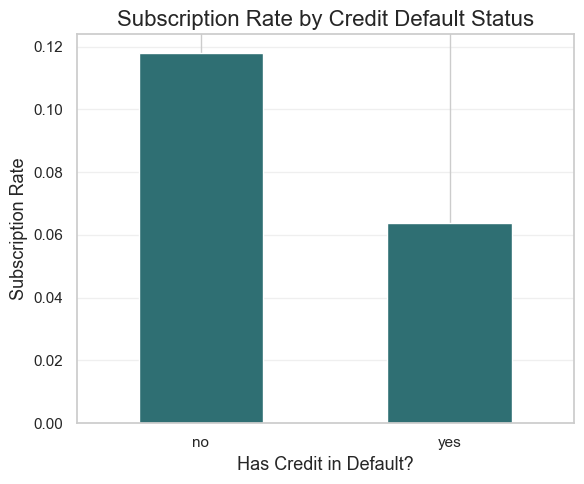

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert subscription target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Calculate subscription rates by default status
default_conversion = df.groupby("default")["subscribed"].mean()

print("Subscription rate by credit default status:")
print(default_conversion)

# 4) Create bar chart
plt.figure(figsize=(6, 5))
default_conversion.plot(kind="bar", color = '#2F6F73')

plt.title("Subscription Rate by Credit Default Status")
plt.xlabel("Has Credit in Default?")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### #Insights
- Customers with credit in default show significantly lower subscription rates.
- Credit risk status may be a strong indicator of low conversion probability.

### Question 5: Is there an interaction between balance and loan status?

Subscription rate by balance quartile and loan status:
loan                      no       yes
balance_bin                           
(-8019.001, 72.0]   0.076031  0.059571
(72.0, 448.0]       0.117660  0.066038
(448.0, 1428.0]     0.134785  0.069235
(1428.0, 102127.0]  0.170809  0.080380


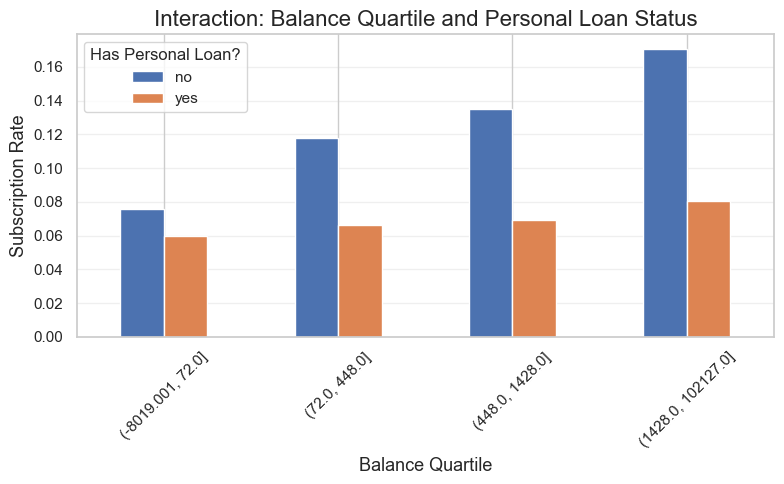

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convertt target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Create balance quartiles
df["balance_bin"] = pd.qcut(df["balance"], q=4, duplicates="drop")

# 4) Group by balance quartile AND personal loan status
interaction = df.groupby(["balance_bin", "loan"])["subscribed"].mean().unstack()

print("Subscription rate by balance quartile and loan status:")
print(interaction)

# 5) Plot grouped bar chart
interaction.plot(kind="bar", figsize=(8,5))

plt.title("Interaction: Balance Quartile and Personal Loan Status")
plt.xlabel("Balance Quartile")
plt.ylabel("Subscription Rate")
plt.legend(title="Has Personal Loan?")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()


plt.show()

### #Insights

If strong interaction:
- High-balance customers without loans have the highest subscription rates.
- Loan status weakens the positive effect of higher balances.

If little interaction:
- Balance increases subscription probability regardless of loan status.
- Loan status does not significantly change the balance effect.

### Question 6: Can subscription likelihood be linked to other products (e.g., loans)

Subscription rates for customers WITH each product:
                   Housing Loan (Yes)  Personal Loan (Yes)  \
Subscription Rate               0.077             0.066814   

                   Credit Default (Yes)  
Subscription Rate              0.063804  


<Figure size 700x500 with 0 Axes>

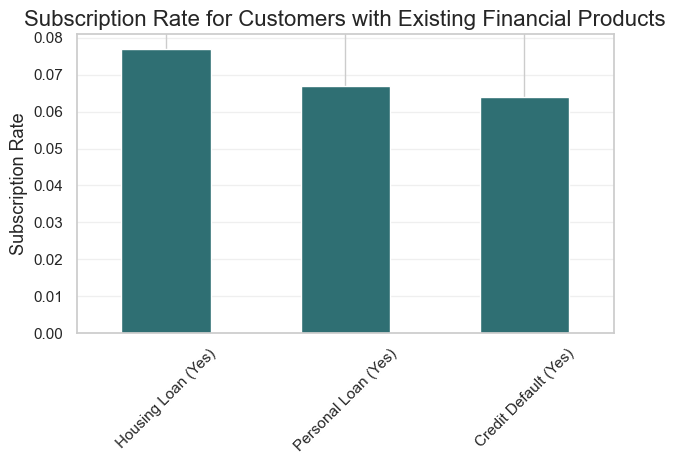

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert subscription to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Calculated subscriptiond rates for each product type
housing_rate = df.groupby("housing")["subscribed"].mean()
personal_rate = df.groupby("loan")["subscribed"].mean()
default_rate = df.groupby("default")["subscribed"].mean()

# 4) Create a comparison table (only "yes" rows for clarity)
comparison = pd.DataFrame({
    "Housing Loan (Yes)": housing_rate["yes"],
    "Personal Loan (Yes)": personal_rate["yes"],
    "Credit Default (Yes)": default_rate["yes"]
}, index=["Subscription Rate"])

print("Subscription rates for customers WITH each product:")
print(comparison)

# 5) Bar chart comparison
plt.figure(figsize=(7,5))
comparison.T.plot(kind="bar", legend=False, color = '#2F6F73')

plt.title("Subscription Rate for Customers with Existing Financial Products")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### #Insights
- Housing loans are significantly more common than personal loans in the dataset.
- Customer debt profile is dominated by housing obligations rather than personal loans.

### Question 7: How many loans are personal vs housing loans?

Housing loan counts:
housing
yes    25130
no     20081
Name: count, dtype: int64

Personal loan counts:
loan
no     37967
yes     7244
Name: count, dtype: int64

Loan comparison:
                     Housing Loans  Personal Loans
Number of Customers          25130            7244


<Figure size 600x500 with 0 Axes>

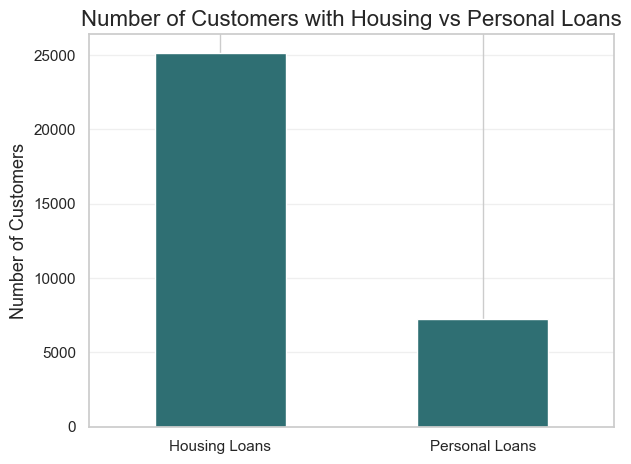

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Count housing loans
housing_counts = df["housing"].value_counts()

# 3) Count personal loans
personal_counts = df["loan"].value_counts()

print("Housing loan counts:")
print(housing_counts)

print("\nPersonal loan counts:")
print(personal_counts)

# 4) Create summary dataframe (only "yes" counts)
loan_summary = pd.DataFrame({
    "Housing Loans": housing_counts["yes"],
    "Personal Loans": personal_counts["yes"]
}, index=["Number of Customers"])

print("\nLoan comparison:")
print(loan_summary)

# 5) Bar chart comparison
plt.figure(figsize=(6,5))
loan_summary.T.plot(kind="bar", legend=False, color = '#2F6F73')

plt.title("Number of Customers with Housing vs Personal Loans")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### #Insights
- Housing loans are significantly more common than personal loans in the dataset.
- Customer debt profile is dominated by housing obligations rather than personal loans.

### Question 8: How much higher or richer does balance need to be to meaningfully increase subscription likelihood?


Balance Percentiles:
0.25      72.0
0.50     448.0
0.75    1428.0
Name: balance, dtype: float64

Subscription rate by balance quartile:
balance_bin
(-8019.001, 72.0]     0.072369
(72.0, 448.0]         0.108936
(448.0, 1428.0]       0.125155
(1428.0, 102127.0]    0.161547
Name: subscribed, dtype: float64

Top 25% balance threshold (75th percentile): € 1428.0


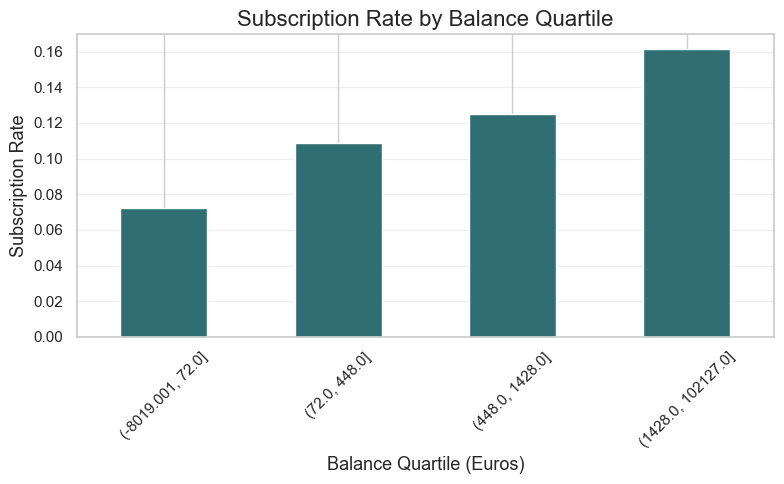

In [69]:
# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert target to numeric (1 = yes, 0 = no)
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Calculate balance percentiles (these help us define what "high balance" means)
percentiles = df["balance"].quantile([0.25, 0.5, 0.75])

print("Balance Percentiles:")
print(percentiles)

# 4) Create balance quartiles (4 equal-sized groups)
df["balance_bin"] = pd.qcut(df["balance"], q=4, duplicates="drop")

# 5) Calculate subscription rate per quartile
conversion_by_bin = df.groupby("balance_bin")["subscribed"].mean()

print("\nSubscription rate by balance quartile:")
print(conversion_by_bin)

# 6) Identify threshold for top quartile
top_threshold = percentiles.loc[0.75]
print("\nTop 25% balance threshold (75th percentile): €", round(top_threshold, 2))

# 7) Bar chart comparison

plt.figure(figsize=(8, 5))
conversion_by_bin.plot(kind="bar", color = '#2F6F73')

plt.title("Subscription Rate by Balance Quartile")
plt.xlabel("Balance Quartile (Euros)")
plt.ylabel("Subscription Rate")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### #Insights
- High income is considered $1,428

# PREVIOUS CAMPAIGN EFFECTIVENESS


### Question 1: Are customers with previous successful campaigns more likely to subscribe again?

Subscription rate comparison:
previous_success
No Previous Success    0.098650
Previous Success       0.647253
Name: subscribed, dtype: float64


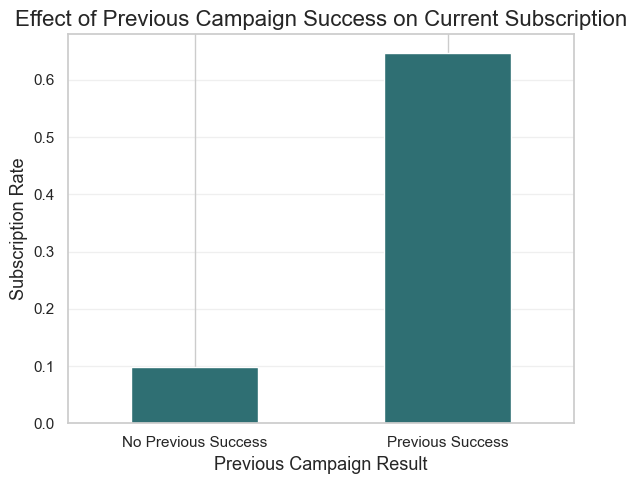

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert subscription target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Create a new column to isolate previous success vs others
df["previous_success"] = df["poutcome"].apply(
    lambda x: "Previous Success" if x == "success" else "No Previous Success"
)

# 4) Calculate subscription rate
success_conversion = df.groupby("previous_success")["subscribed"].mean()

print("Subscription rate comparison:")
print(success_conversion)

# 5) Plot bar chart
plt.figure(figsize=(6,5))
success_conversion.plot(kind="bar", color = '#2F6F73')

plt.title("Effect of Previous Campaign Success on Current Subscription")
plt.xlabel("Previous Campaign Result")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

# plt.savefig("png_previouscampaign/02_previous_success_vs_subscription.png", dpi=300)

plt.show()

### Key Variables: poutcome, y, subscribed

### #Insights 
- Customers who previously subscribed are significantly more likely to subscribe again.
- Prior campaign success is one of the strongest predictors of current conversion.

### Question 2: Are customers who previously declined campaign offers more likely to subscribe in a future campaign?

Subscription rate comparison:
previous_failure
No Previous Failure    0.115877
Previous Failure       0.126097
Name: subscribed, dtype: float64


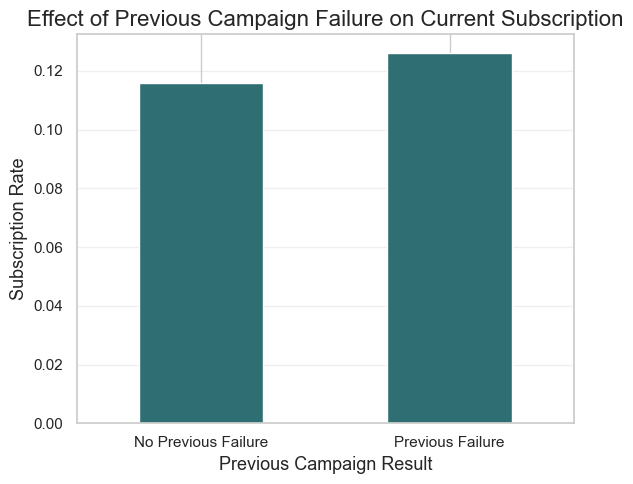

In [77]:
# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert subscription target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Create a new column to isolate previous failure vs others
df["previous_failure"] = df["poutcome"].apply(
    lambda x: "Previous Failure" if x == "failure" else "No Previous Failure"
)

# 4) Calculate subscription rate
failure_conversion = df.groupby("previous_failure")["subscribed"].mean()

print("Subscription rate comparison:")
print(failure_conversion)

# 5) Plot bar chart
plt.figure(figsize=(6,5))
failure_conversion.plot(kind="bar", color = '#2F6F73')

plt.title("Effect of Previous Campaign Failure on Current Subscription")
plt.xlabel("Previous Campaign Result")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### Key Variables: poutcome, y, subscribed

### #Insights 
- Customers who previously failed to subscribe show lower conversion rates in the current campaign.
- Repeatedly targeting previously unsuccessful customers may lead to diminishing returns.

### Question 3: Does time since last contact (pdays) influence success probability?

Subscription rate by pdays group:
pdays_group
0–30 Days          0.148936
31–90 Days         0.420755
90+ Days           0.219392
Never Contacted    0.091573
Name: subscribed, dtype: float64


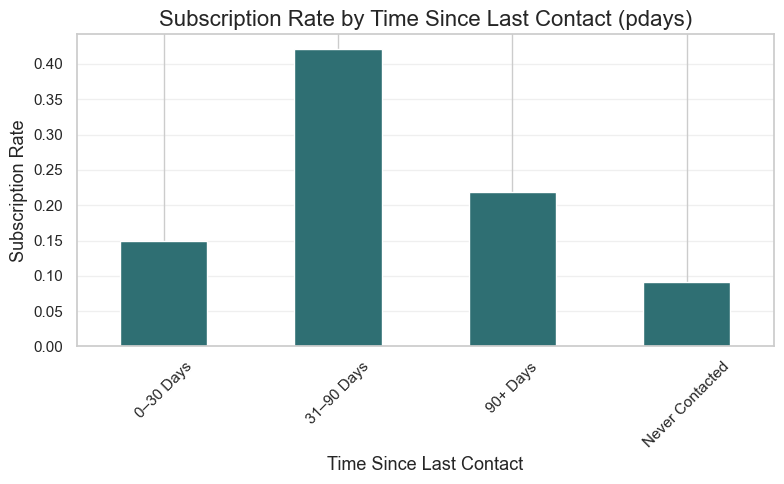

In [78]:
# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert subscription to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Create pdays categories
def categorize_pdays(x):
    if x == -1:
        return "Never Contacted"
    elif x <= 30:
        return "0–30 Days"
    elif x <= 90:
        return "31–90 Days"
    else:
        return "90+ Days"

df["pdays_group"] = df["pdays"].apply(categorize_pdays)

# 4) Calculate subscription rate by pdays group
pdays_conversion = df.groupby("pdays_group")["subscribed"].mean()

print("Subscription rate by pdays group:")
print(pdays_conversion)

# 5) Plot bar chart
plt.figure(figsize=(8,5))
pdays_conversion.plot(kind="bar", color = '#2F6F73')

plt.title("Subscription Rate by Time Since Last Contact (pdays)")
plt.xlabel("Time Since Last Contact")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### Key Variables: pdays, y, subscribed

### #Insights 
- Customers contacted more recently show higher subscription rates.
- Subscription likelihood decreases as time since last contact increases.
- Recency appears to be an important driver of campaign effectiveness.

### Question 4: Are existing customers more likely to subscribe than new ones?

Subscription rate by customer type:
customer_type
Existing Customer    0.230713
New Customer         0.091573
Name: subscribed, dtype: float64


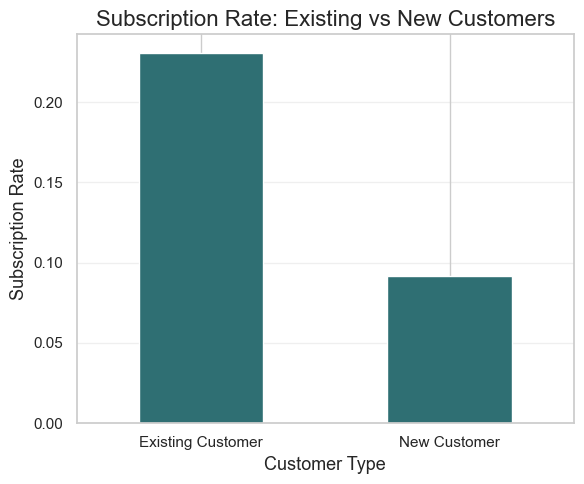

In [79]:
# 1) Load dataset
df = pd.read_csv("../data/processed/bank-full-clean.csv", sep=",")

# 2) Convert subscription to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Create customer type column
df["customer_type"] = df["pdays"].apply(
    lambda x: "Existing Customer" if x != -1 else "New Customer"
)

# 4) Calculate subscription rate
customer_conversion = df.groupby("customer_type")["subscribed"].mean()

print("Subscription rate by customer type:")
print(customer_conversion)

# 5) Plot bar chart
plt.figure(figsize=(6,5))
customer_conversion.plot(kind="bar", color = '#2F6F73')

plt.title("Subscription Rate: Existing vs New Customers")
plt.xlabel("Customer Type")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()


plt.show()

### Key Variables: pdays, y, subscribed

### #Insights 
- Existing customers generally show higher subscription rates than new customers.
- Prior engagement increases likelihood of conversion.
- Retargeting known customers may be more efficient than focusing only on new prospects.

### Question 5: How does the subscription rate vary across months?

/var/folders/m9/3qw5qv8x7bdb20d_n3wnbqpm0000gn/T/ipykernel_42235/3449376824.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='only_yes', data=month_success, palette=month_success['color'].tolist())


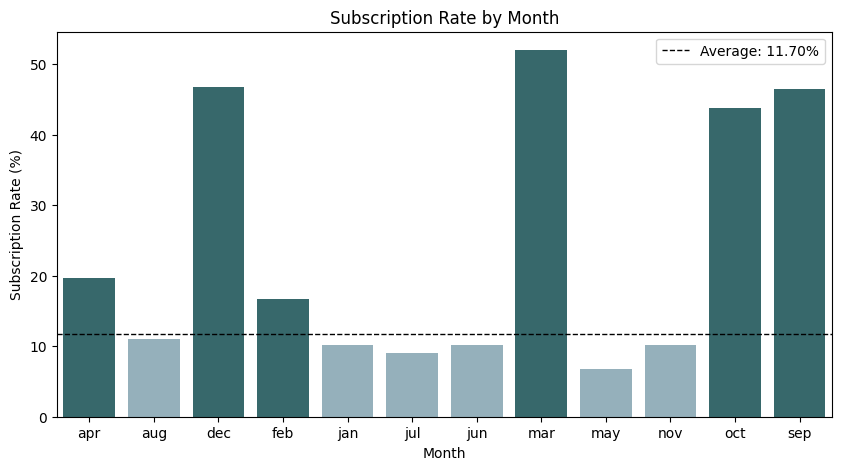

In [6]:
eda_df = df.copy()
eda_df['only_yes'] = (eda_df['y'] == 'yes').astype(int)
month_success = eda_df.groupby('month')['only_yes'].mean().mul(100).reset_index()
overall_avg = eda_df['only_yes'].mean() * 100

plt.figure(figsize=(10,5))
month_success['color'] = month_success['only_yes'].apply(lambda x: '#2F6F73' if x >= overall_avg else '#8FB3C1')
sns.barplot(x='month', y='only_yes', data=month_success, palette=month_success['color'].tolist())
plt.axhline(overall_avg, color='black', linestyle='--', linewidth=1, label=f'Average: {overall_avg:.2f}%')
plt.title('Subscription Rate by Month')
plt.ylabel('Subscription Rate (%)')
plt.xlabel('Month')
plt.legend()
plt.show()

### #Insights 
- Subscription rates are higher in specific months. March stands out with the highest subscription rate (over 50%). September, October, and December also have subscription rates well above the average line.

### Question 6: How does call duration relate to subscription? 

/var/folders/m9/3qw5qv8x7bdb20d_n3wnbqpm0000gn/T/ipykernel_42235/1949331431.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='duration_bin', y='only_yes', data=duration_success, palette=duration_success['color'].tolist())


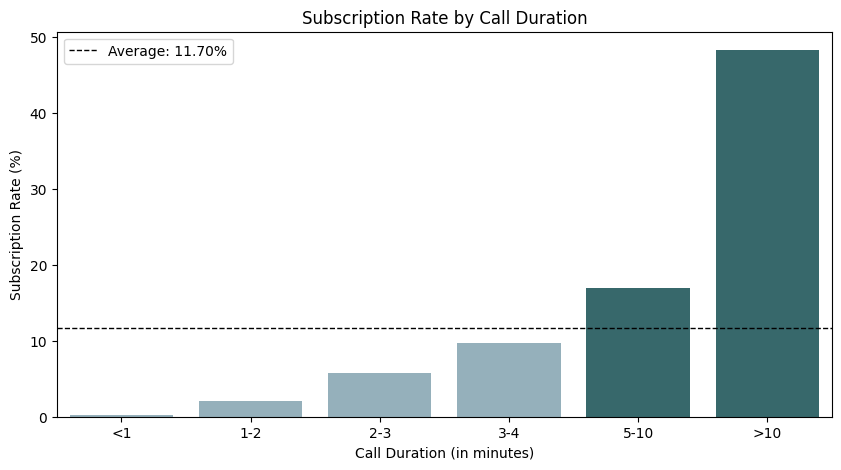

In [7]:
# define bins (in minutes)
bins = [0, 1, 2, 3, 4, 10, eda_df['duration'].max()+1]
labels = ['<1','1-2','2-3','3-4','5-10','>10']
# create bins
eda_df['duration_bin'] = pd.cut(eda_df['duration']/60, bins=bins, labels=labels, right=False)

duration_success = eda_df.groupby('duration_bin')['only_yes'].mean().mul(100).reset_index()

plt.figure(figsize=(10,5))
duration_success['color'] = duration_success['only_yes'].apply(lambda x: '#2F6F73' if x >= overall_avg else '#8FB3C1')
sns.barplot(x='duration_bin', y='only_yes', data=duration_success, palette=duration_success['color'].tolist())
plt.axhline(overall_avg, color='black', linestyle='--', linewidth=1, label=f'Average: {overall_avg:.2f}%')
plt.ylabel('Subscription Rate (%)')
plt.xlabel('Call Duration (in minutes)')
plt.title('Subscription Rate by Call Duration')
plt.legend()
plt.show()

### #Insights  
- Longer calls lead to more subscriptions. Spending more time talking helps convince customers, while very short calls rarely work. To get better results, calls should last at least 5 minutes.

### Question 7: Does subscription probability decrease after too many calls?

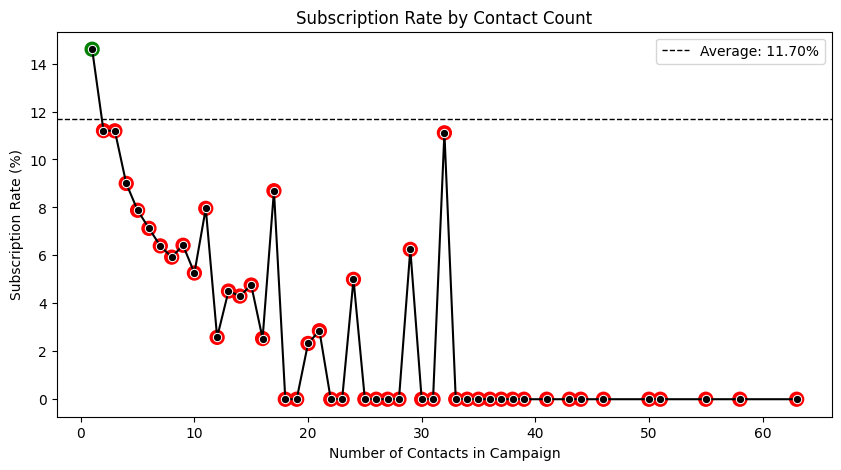

In [8]:
contact_success = eda_df.groupby('campaign')['only_yes'].mean().mul(100).reset_index()

contact_success['color'] = contact_success['only_yes'].apply(lambda x: 'green' if x >= overall_avg else 'red')
plt.figure(figsize=(10,5))
sns.lineplot(data=contact_success, x='campaign', y='only_yes', marker='o', color='black')
plt.scatter(contact_success['campaign'], contact_success['only_yes'], color=contact_success['color'], s=100)
plt.axhline(overall_avg, color='black', linestyle='--', linewidth=1, label=f'Average: {overall_avg:.2f}%')
plt.title('Subscription Rate by Contact Count')
plt.xlabel('Number of Contacts in Campaign')
plt.ylabel('Subscription Rate (%)')
plt.legend()
plt.show()

### #Insights 
- We can see a strong inverse relationship between contact frequency and subscription rate. Clients contacted only once converted at ~14.8%, while rates drop sharply and consistently as contact count increases, with a few spikes, but these remain below the average subscription rate.

### Question 8: Are customers with previous successful campaigns significantly more likely to subscribe again?

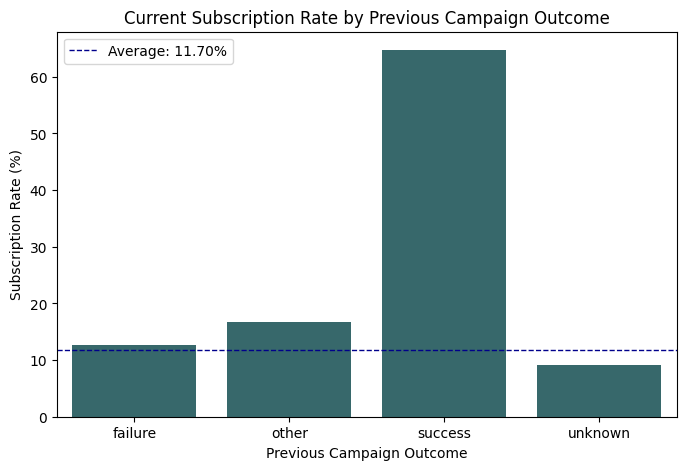

In [9]:
prev_outcome = eda_df.groupby('poutcome')['only_yes'].mean().mul(100).reset_index()

plt.figure(figsize=(8,5))
plt.axhline(overall_avg, color='darkblue', linestyle='--', linewidth=1, label=f'Average: {overall_avg:.2f}%')
sns.barplot(data=prev_outcome, x='poutcome', y='only_yes', color = '#2F6F73')
plt.title('Current Subscription Rate by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Subscription Rate (%)')
plt.legend()
plt.show()

### #Insights 
- Customers with previous campaign success have significantly higher subscription rates.
- Customers with previous campaign failure are much less likely to convert.
- Retargeting previously successful customers appears highly effective.

### Question 9: Does how we contact the customer matter?

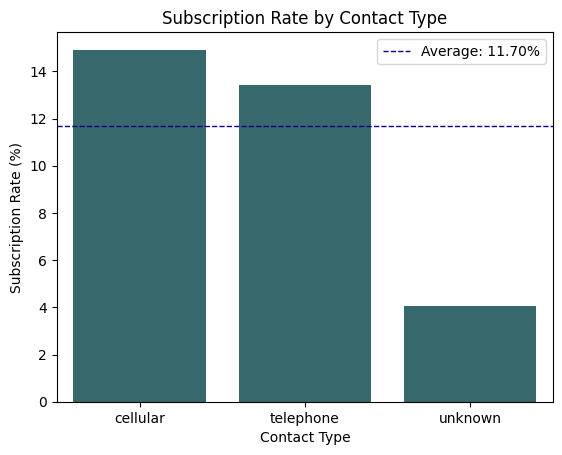

In [10]:
contact_type_success = eda_df.groupby('contact')['only_yes'].mean().mul(100).reset_index()

sns.barplot(data=contact_type_success, x="contact", y="only_yes", color = '#2F6F73')
plt.axhline(overall_avg, color='darkblue', linestyle='--', linewidth=1, label=f'Average: {overall_avg:.2f}%')

plt.title('Subscription Rate by Contact Type')
plt.xlabel('Contact Type')
plt.ylabel('Subscription Rate (%)')
plt.legend()
plt.show()

### #Insights
- Both contact methods are effective, with the cellular method having a slight, but not significant, advantage.